# Consumer Complaint Classification

## 1. Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Results

In [43]:
simplernn = pd.read_csv(
    "/kaggle/input/datasets/mohamedafifi77/results/simplernn_results.csv"
)

lstm = pd.read_csv(
    "/kaggle/input/datasets/mohamedafifi77/results/lstm_results.csv"
)

gru = pd.read_csv(
    "/kaggle/input/datasets/mohamedafifi77/results/gru_results.csv"
)

distilbert = pd.read_csv(
    "/kaggle/input/datasets/mohamedafifi77/results/distilbert_results.csv"
)

## 3. Combine Results

In [44]:
results = pd.concat(
    [
        simplernn,
        lstm,
        gru,
        distilbert
    ],
    ignore_index=True
)

results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,SimpleRNN,0.761075,0.602694,0.636598,0.591822
1,LSTM,0.882092,0.845577,0.848804,0.846911
2,GRU,0.883724,0.847025,0.851641,0.849067
3,DistilBERT,0.897177,0.873407,0.856639,0.864658


## 4. Performance Comparison Table

In [45]:
results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results.reset_index(drop=True, inplace=True)

results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,DistilBERT,0.897177,0.873407,0.856639,0.864658
1,GRU,0.883724,0.847025,0.851641,0.849067
2,LSTM,0.882092,0.845577,0.848804,0.846911
3,SimpleRNN,0.761075,0.602694,0.636598,0.591822


## 5. Accuracy Comparison

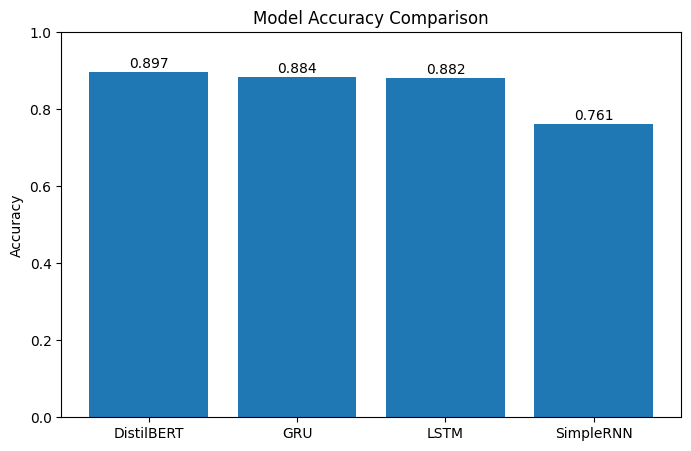

In [46]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

for i, v in enumerate(results["Accuracy"]):
    plt.text(i, v+0.01, f"{v:.3f}", ha="center")

plt.savefig(
    "/kaggle/working/accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Precision Comparison

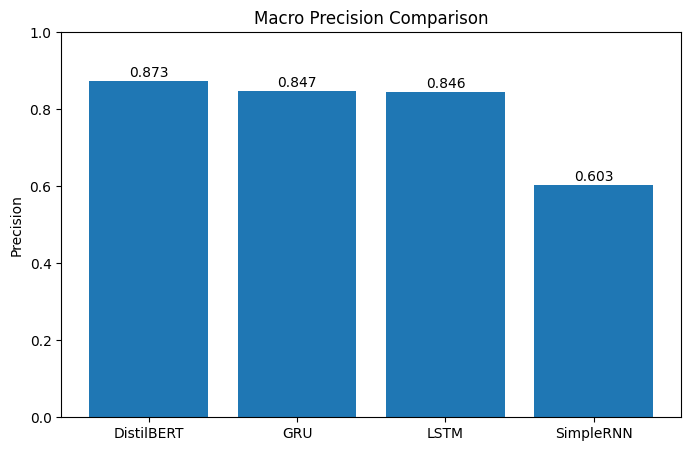

In [47]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Macro Precision"])

plt.title("Macro Precision Comparison")
plt.ylabel("Precision")
plt.ylim(0,1)

for i, v in enumerate(results["Macro Precision"]):
    plt.text(i, v+0.01, f"{v:.3f}", ha="center")

plt.savefig(
    "/kaggle/working/precision_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Recall Comparison

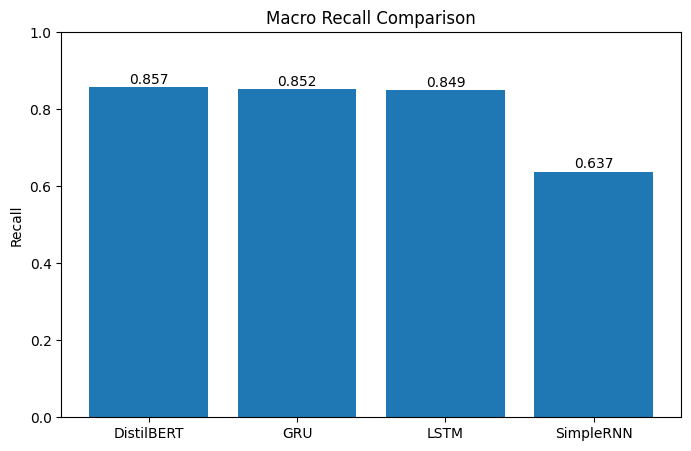

In [48]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Macro Recall"])

plt.title("Macro Recall Comparison")
plt.ylabel("Recall")
plt.ylim(0,1)

for i, v in enumerate(results["Macro Recall"]):
    plt.text(i, v+0.01, f"{v:.3f}", ha="center")

plt.savefig(
    "/kaggle/working/recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Macro F1 Comparison

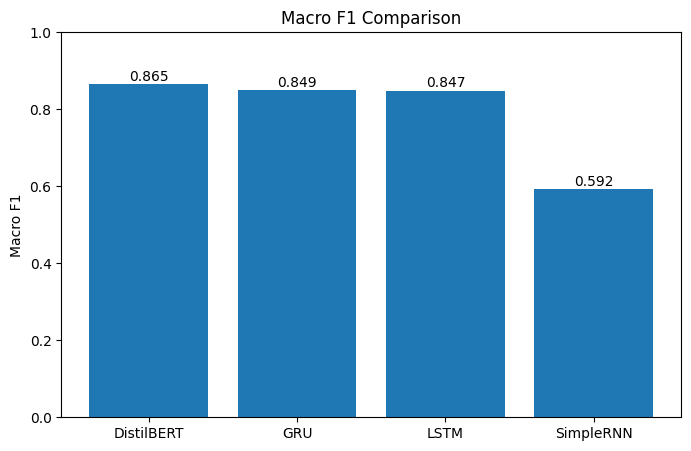

In [49]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Macro F1"])

plt.title("Macro F1 Comparison")
plt.ylabel("Macro F1")
plt.ylim(0,1)

for i, v in enumerate(results["Macro F1"]):
    plt.text(i, v+0.01, f"{v:.3f}", ha="center")

plt.savefig(
    "/kaggle/working/f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Model Ranking

In [50]:
ranking = results.sort_values(
    by=["Accuracy", "Macro F1"],
    ascending=False
).reset_index(drop=True)

ranking.index = ranking.index + 1

ranking

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,DistilBERT,0.897177,0.873407,0.856639,0.864658
2,GRU,0.883724,0.847025,0.851641,0.849067
3,LSTM,0.882092,0.845577,0.848804,0.846911
4,SimpleRNN,0.761075,0.602694,0.636598,0.591822


In [51]:
print("🏆 Final Model Ranking\n")

for i, row in ranking.iterrows():
    print(
        f"{i}. {row['Model']} | "
        f"Accuracy={row['Accuracy']:.4f} | "
        f"Macro F1={row['Macro F1']:.4f}"
    )

🏆 Final Model Ranking

1. DistilBERT | Accuracy=0.8972 | Macro F1=0.8647
2. GRU | Accuracy=0.8837 | Macro F1=0.8491
3. LSTM | Accuracy=0.8821 | Macro F1=0.8469
4. SimpleRNN | Accuracy=0.7611 | Macro F1=0.5918


## 10. Conclusion

In [52]:
best_model = ranking.iloc[0]

print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print(f"Model           : {best_model['Model']}")
print(f"Accuracy        : {best_model['Accuracy']:.4f}")
print(f"Macro Precision : {best_model['Macro Precision']:.4f}")
print(f"Macro Recall    : {best_model['Macro Recall']:.4f}")
print(f"Macro F1        : {best_model['Macro F1']:.4f}")

BEST MODEL
Model           : DistilBERT
Accuracy        : 0.8972
Macro Precision : 0.8734
Macro Recall    : 0.8566
Macro F1        : 0.8647


In [53]:
ranking.to_csv(
    "/kaggle/working/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.
